In [1]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install scikit-learn
!pip install xgboost
!pip install streamlit

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.1 MB/s eta 0:01:06
   ---------------------------------------- 0.8/69.5 MB 1.3 MB/s eta 0:00:52
    --------------------------------------- 1.0/69.5 MB 1.2 MB/s eta 0:00:56
    --------------------------------------- 1.0/69.5 MB 1.2 MB/s eta 0:00:56
    --------------------------------------- 1.3/69.5 MB 927.6 kB/s eta 0:01:14
    --------------------------------------- 1.6/69.5 

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(r"C:\Users\acer\Downloads\zomato_restaurants_in_India.csv")

In [5]:
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [6]:
df.info()             
df.describe(include="all")  
df.isnull().sum()     


<class 'pandas.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  str    
 2   establishment         211944 non-null  str    
 3   url                   211944 non-null  str    
 4   address               211810 non-null  str    
 5   city                  211944 non-null  str    
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  str    
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   str    
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  str    
 13  cuisines              210553 non-null  str    
 14  timings               208070 non-null  str    
 15  average_cos

res_id                       0
name                         0
establishment                0
url                          0
address                    134
city                         0
city_id                      0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
country_id                   0
locality_verbose             0
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
opentable_support           48
delivery                     0
takeaway                     0
dtype: int64

In [7]:
# Drop rows with missing ratings (already clean, so skip)
# Handle missing address and zipcode
df["address"] = df["address"].fillna("Unknown")
df["zipcode"] = df["zipcode"].fillna("000000")

# Handle missing cuisines and timings
df["cuisines"] = df["cuisines"].fillna("Unknown")
df["timings"] = df["timings"].fillna("Not Available")

# Handle opentable_support
df["opentable_support"] = df["opentable_support"].fillna(0)


In [8]:
df.isnull().sum()

res_id                  0
name                    0
establishment           0
url                     0
address                 0
city                    0
city_id                 0
locality                0
latitude                0
longitude               0
zipcode                 0
country_id              0
locality_verbose        0
cuisines                0
timings                 0
average_cost_for_two    0
price_range             0
currency                0
highlights              0
aggregate_rating        0
rating_text             0
votes                   0
photo_count             0
opentable_support       0
delivery                0
takeaway                0
dtype: int64

In [9]:
df.to_csv("zomato_cleaned.csv", index=False)

In [10]:
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


1.Find which cuisines dominate across India

C:\Users\acer\AppData\Local\Temp\ipykernel_13384\1937066111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.index, y=top_cuisines.values, palette="viridis")


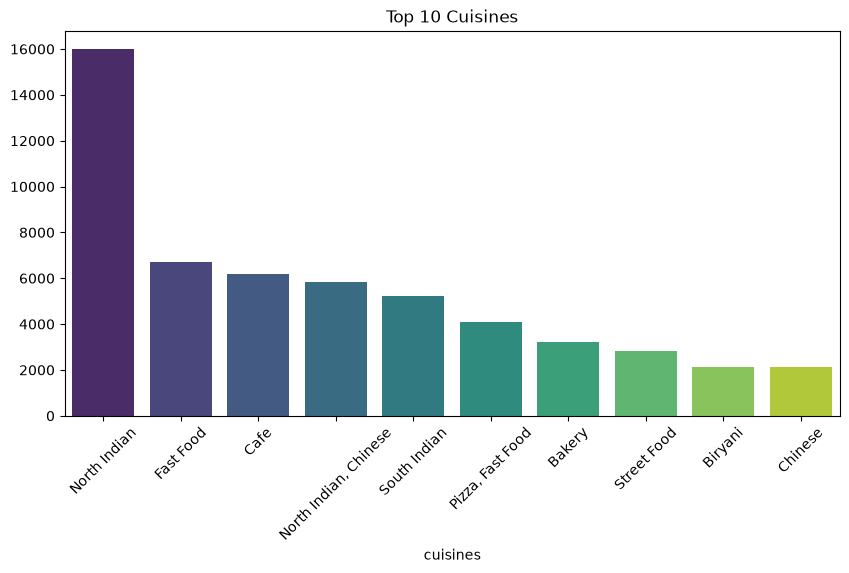

In [12]:
top_cuisines = df["cuisines"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisines.index, y=top_cuisines.values, palette="viridis")
plt.title("Top 10 Cuisines")
plt.xticks(rotation=45)
plt.show()

2.Average Cost By City

C:\Users\acer\AppData\Local\Temp\ipykernel_13384\881075164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_cost.index, y=city_cost.values, palette="magma")


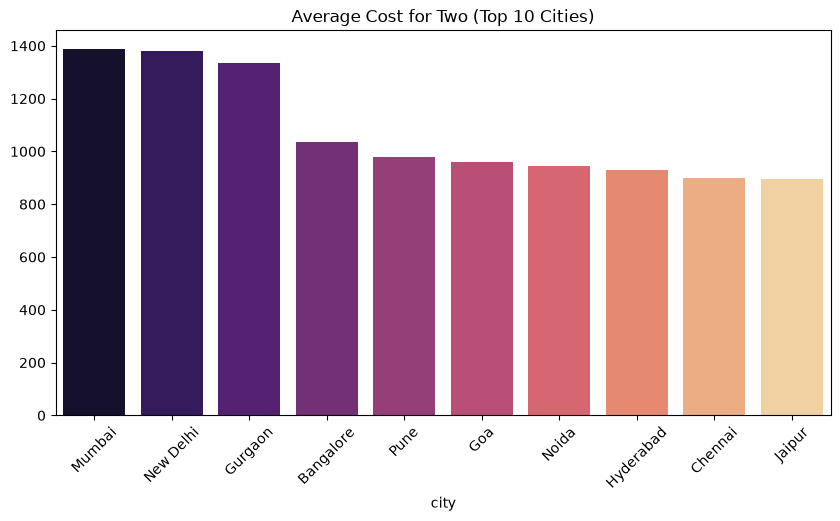

In [13]:
city_cost = df.groupby("city")["average_cost_for_two"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=city_cost.index, y=city_cost.values, palette="magma")
plt.title("Average Cost for Two (Top 10 Cities)")
plt.xticks(rotation=45)
plt.show()

3.How the restaurant ratings are spread

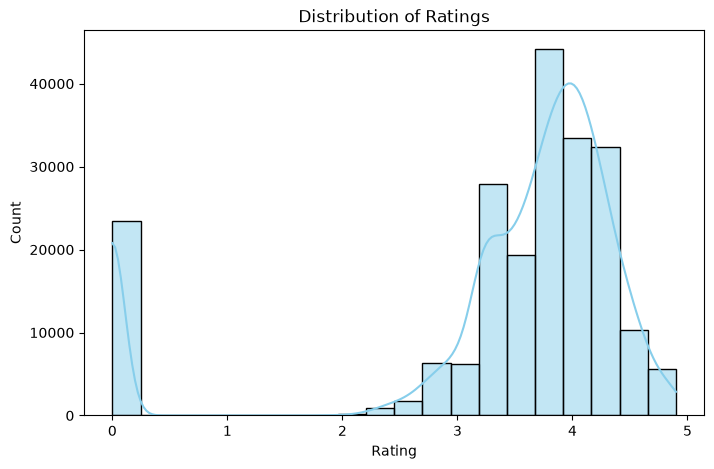

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["aggregate_rating"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

4.Compare availability of delivery and takeaway

C:\Users\acer\AppData\Local\Temp\ipykernel_13384\117414457.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="delivery", data=df, ax=ax[0], palette="cool")
C:\Users\acer\AppData\Local\Temp\ipykernel_13384\117414457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="takeaway", data=df, ax=ax[1], palette="coolwarm")


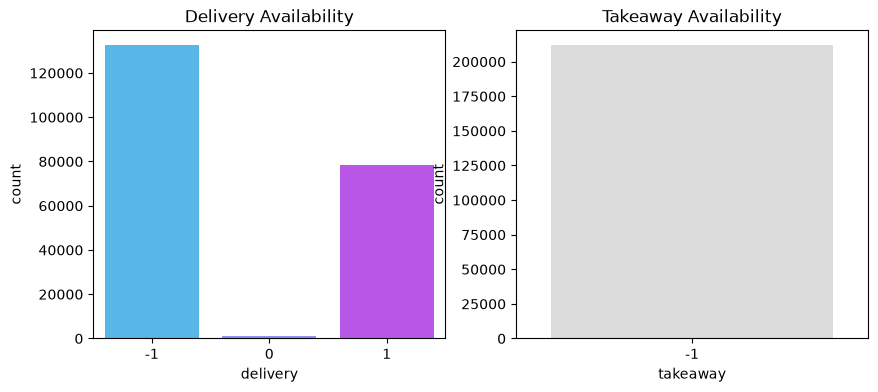

In [15]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.countplot(x="delivery", data=df, ax=ax[0], palette="cool")
sns.countplot(x="takeaway", data=df, ax=ax[1], palette="coolwarm")
ax[0].set_title("Delivery Availability")
ax[1].set_title("Takeaway Availability")
plt.show()

ADVANCED EDA


I analyze relationship between variables


1.Correaltion heatmaps of cost,rating and votes

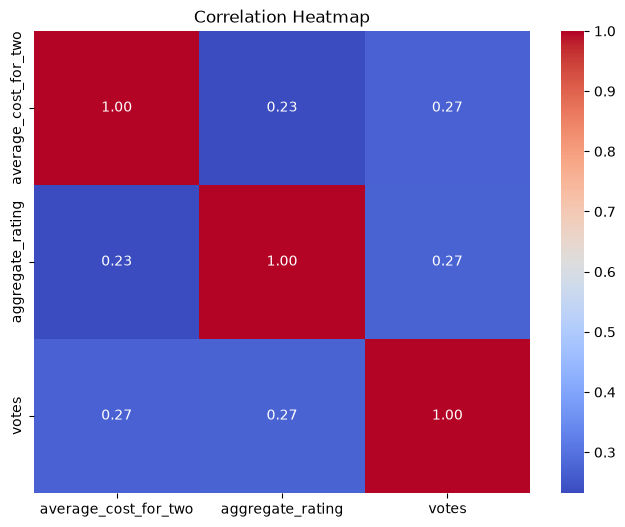

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["average_cost_for_two","aggregate_rating","votes"]].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

2.Scatterplot of cost vs rating

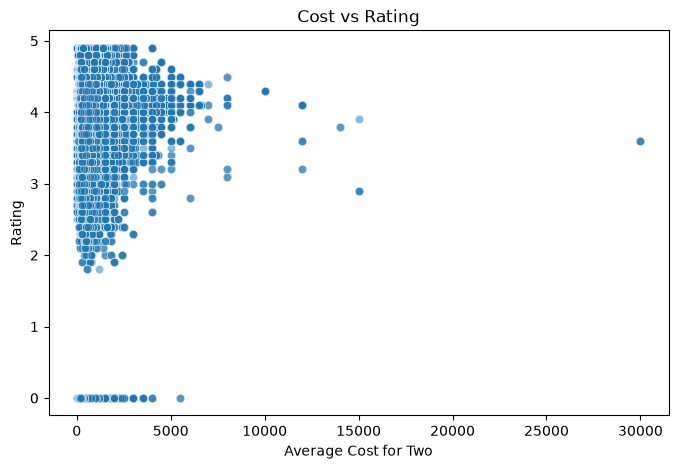

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="average_cost_for_two", y="aggregate_rating", data=df, alpha=0.5)
plt.title("Cost vs Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Rating")
plt.show()


3.Scatterplots of votes vs rating

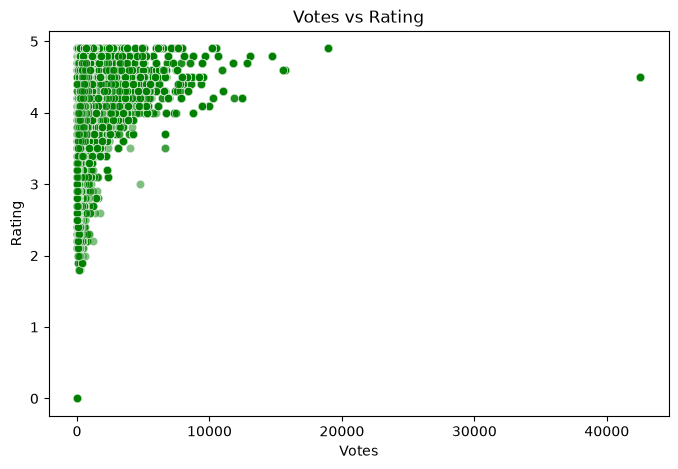

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="votes", y="aggregate_rating", data=df, alpha=0.5, color="green")
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()


4.Average rating comparision for delivery vs non-delivery restaurants

In [19]:
delivery_rating = df.groupby("delivery")["aggregate_rating"].mean()
print(delivery_rating)


delivery
-1    3.193217
 0    3.365058
 1    3.739424
Name: aggregate_rating, dtype: float64


## ML Model
In this step, I build a predictive model to estimate restaurant ratings.
- Encoded categorical features (city, cuisines).
- Selected features: average cost, votes, city, cuisine.
- Trained a Random Forest Regressor.
- Evaluated performance using Mean Squared Error and R² Score.



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
df["city_encoded"] = le_city.fit_transform(df["city"])

le_cuisine = LabelEncoder()
df["cuisine_encoded"] = le_cuisine.fit_transform(df["cuisines"])


X = df[["average_cost_for_two","votes","city_encoded","cuisine_encoded"]]
y = df["aggregate_rating"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Mean Squared Error: 0.0370866132621201
R² Score: 0.9774138120510566
